# 4Dwire demo

The multi-view implementation is in [`wire4d.py`](wire4d.py), and the surface filling curve workflow is in [`surface_filling.py`](surface_filling.py). This notebook renders bundled checkpoints on CPU and displays results included in `examples/results/`. Training requires a CUDA GPU and a Stable Diffusion model download.

## Setup

Start Jupyter from the project directory with the `diffvg` conda environment. Rendered files go to `outputs/`.

In [1]:
from IPython.display import Image, display
from wire4d import render_sample_dreamwire, render_sample_bspline

## DreamWire: three orthogonal views

Load the bundled multi-path control points and render the front, side, and top views.

Loading from /home/tobi/4Dwire/inputs/points_final.pt...
detected: 39 paths, 4 segments per path.
✅ Model successfully updated from checklist.


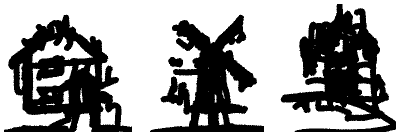

In [2]:
dreamwire_image = render_sample_dreamwire(size=128, device="cpu")
display(Image(filename=str(dreamwire_image)))

## B-spline: three orthogonal views

Load the bundled single-wire checkpoint and render the same three views.

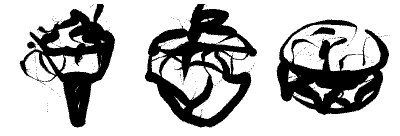

In [3]:
bspline_image = render_sample_bspline(size=128, device="cpu")
display(Image(filename=str(bspline_image)))

## Run training

Full Stable Diffusion optimization needs a CUDA GPU. The script exposes `train-bspline` and `train-dreamwire` commands; see the README for examples.

## Prompt examples: short GPU trials

The following three prompt sets came from `inputs/prompt.json` and ran for **50 optimization steps each with a 50-step noise schedule** on the RTX 3090. These are pipeline checks, not converged artwork; the original experiment uses 1,801 steps.

cat: 50 steps, 44.0 s
a simple drawing of a cute cat on a white background | a portrait of a cute dog on a white background | a sketch of a cute bird on a white background


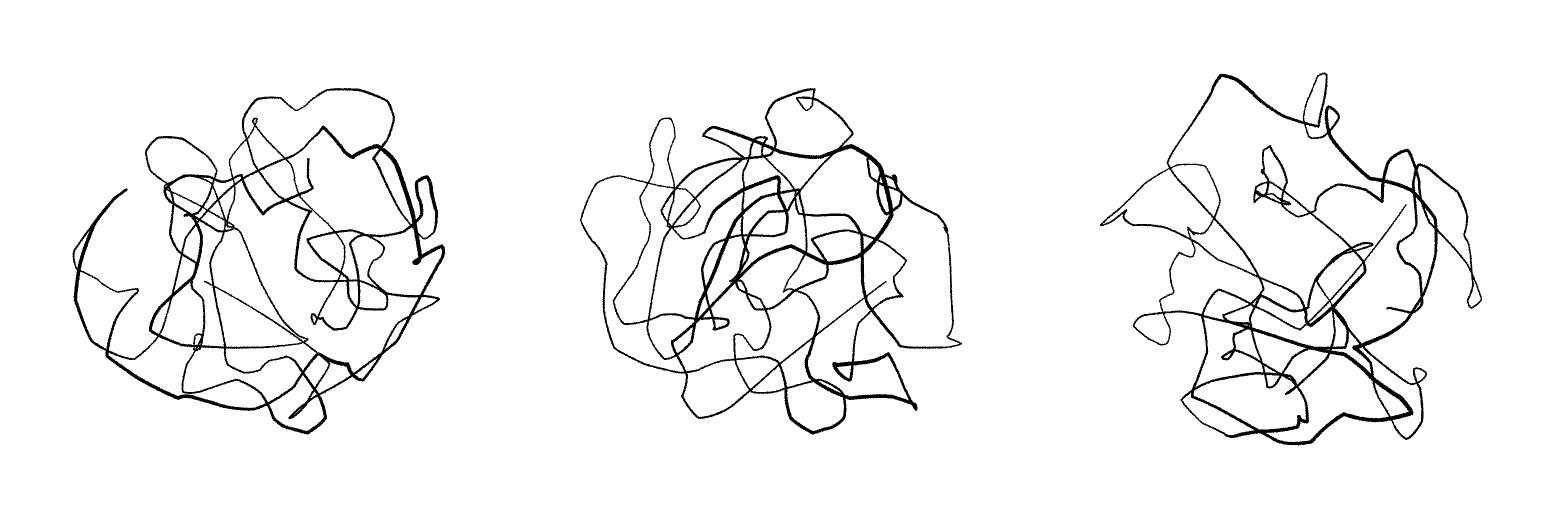

food: 50 steps, 44.4 s
a simple sketch of a delicious ice cream cone on a white background | a minimalist line drawing of an apple on a white background | a simple drawing of a hamburger on a white background


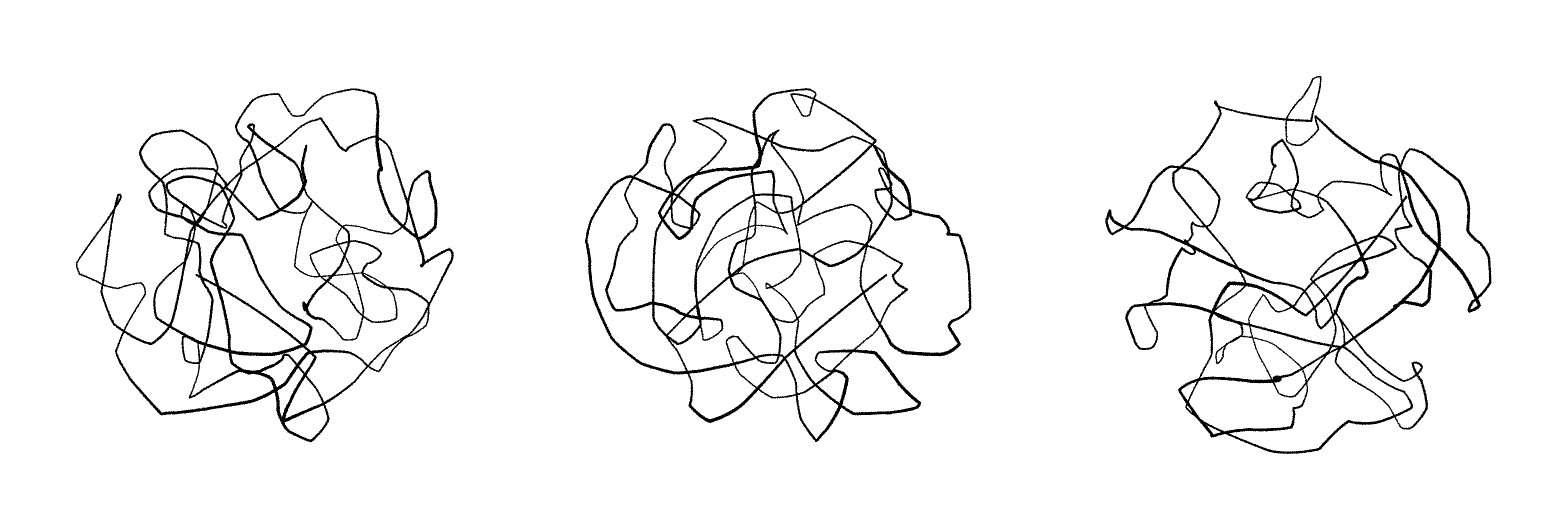

vehicles: 50 steps, 45.2 s
a simple outline sketch of a vintage beetle car on a white background | a minimalist side view drawing of a vespa scooter on a white background | a line art sketch of a steam train locomotive on a white background


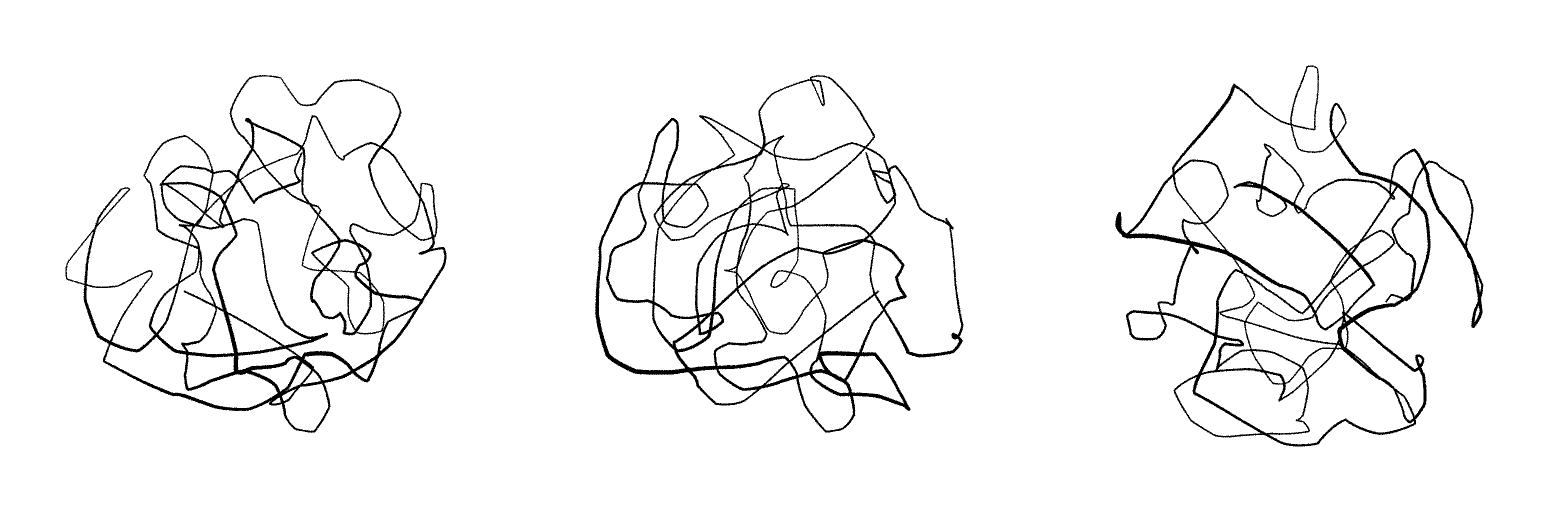

In [4]:
from pathlib import Path
import json

for prompt_set in ("cat", "food", "vehicles"):
    run_dir = Path("examples/results/short") / prompt_set
    result = json.loads((run_dir / "run.json").read_text())
    print(f"{prompt_set}: {result['steps']} steps, {result['elapsed_seconds']} s")
    print(" | ".join(result["prompts"]))
    display(Image(filename=str(run_dir / "final_views.png")))

## Food prompt: 1,000 notebook-matched iterations

This run follows the original notebook settings through step 999: seed 365, 210 keypoints, the `food` prompts, and noise annealing based on 1,801 steps. It ran on the RTX 3090. The views suggest an ice cream cone, apple, and hamburger.

food: 1000 steps (schedule 1801) in 902.8 seconds
a simple sketch of a delicious ice cream cone on a white background | a minimalist line drawing of an apple on a white background | a simple drawing of a hamburger on a white background


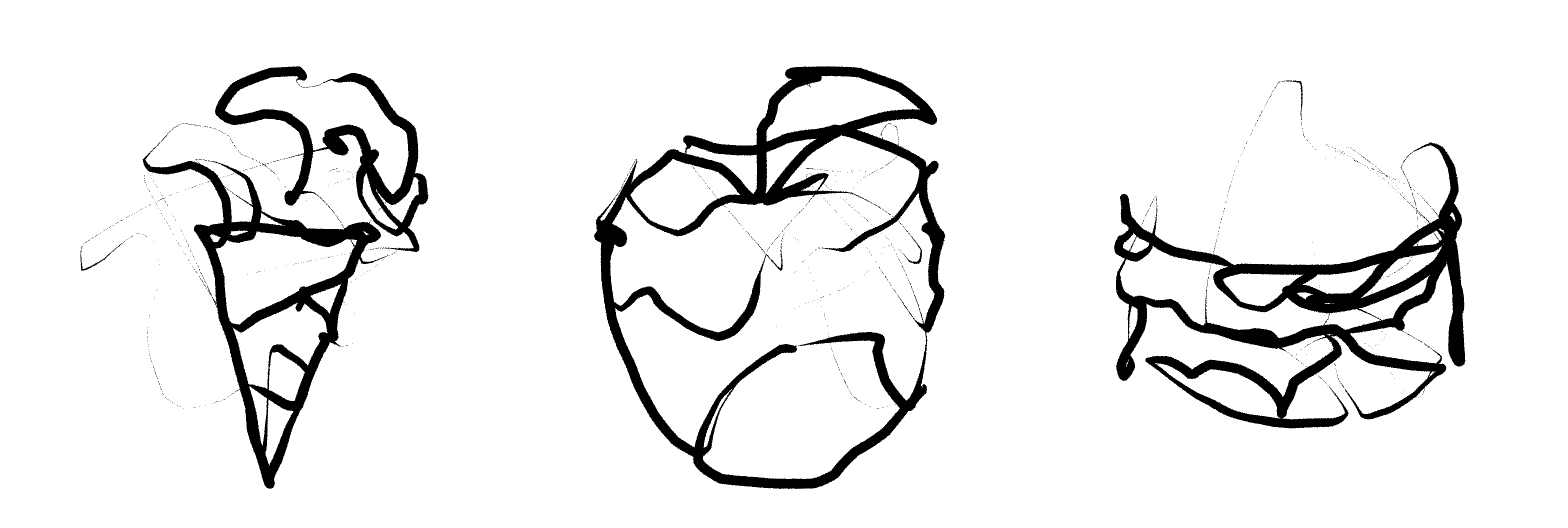

In [5]:
full_run = Path("examples/results/1000/food")
full_result = json.loads((full_run / "run.json").read_text())
print(f"{full_result['prompt_set']}: {full_result['steps']} steps (schedule {full_result['schedule_steps']}) in {full_result['elapsed_seconds']} seconds")
print(" | ".join(full_result["prompts"]))
display(Image(filename=str(full_run / "final_views.png")))

## Cat and vehicles: 1,000 notebook-matched iterations

Both runs use seed 365 and the original notebook's 1,801-step noise schedule. The `cat` set targets cat, dog, and bird views; `vehicles` targets car, scooter, and train views. The saved checkpoints were reloaded successfully.

cat: 1000 steps (schedule 1801) in 885.3 s
a simple drawing of a cute cat on a white background | a portrait of a cute dog on a white background | a sketch of a cute bird on a white background


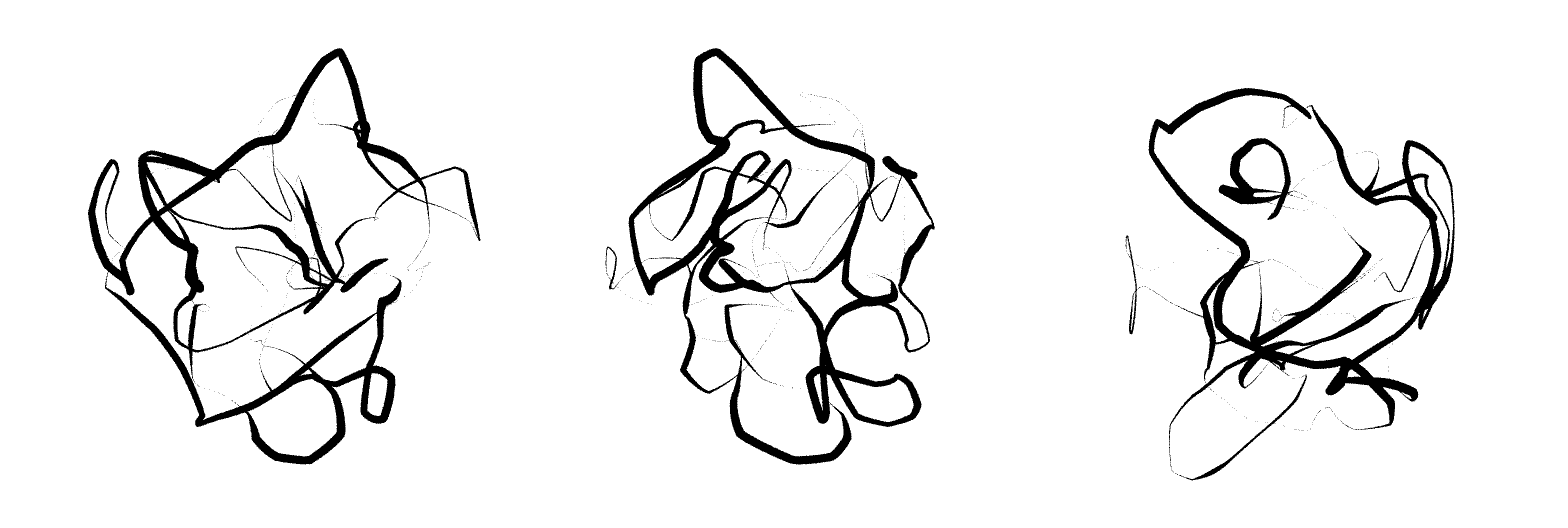

vehicles: 1000 steps (schedule 1801) in 893.3 s
a simple outline sketch of a vintage beetle car on a white background | a minimalist side view drawing of a vespa scooter on a white background | a line art sketch of a steam train locomotive on a white background


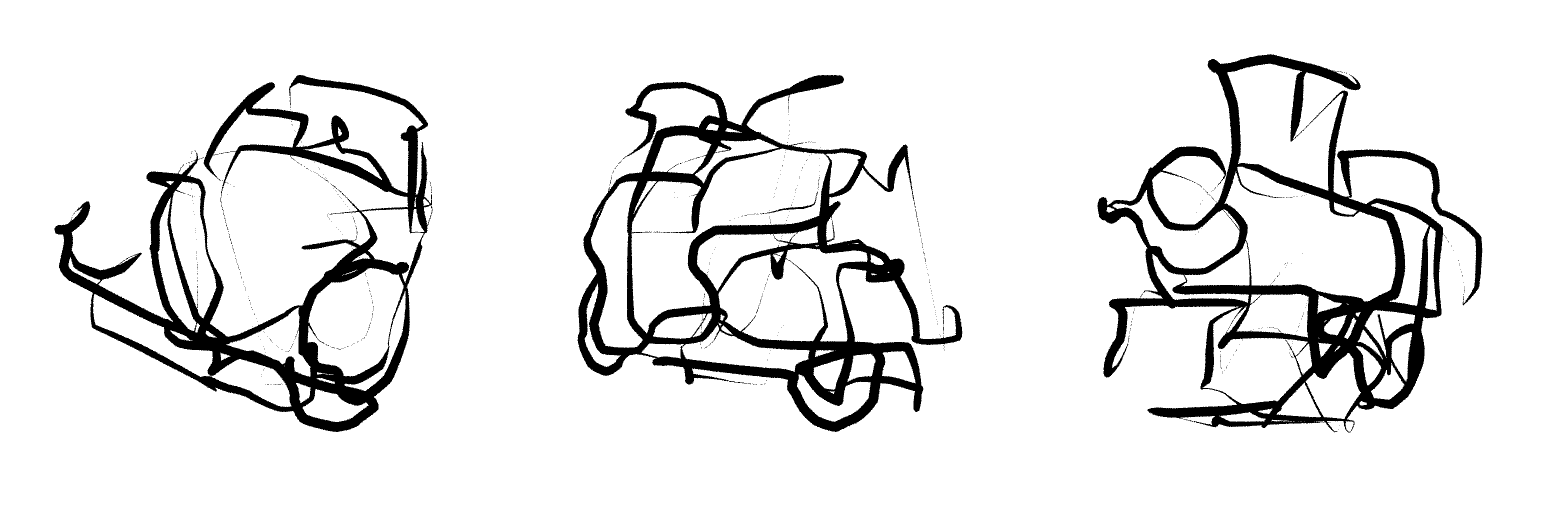

In [6]:
for prompt_set in ("cat", "vehicles"):
    run_dir = Path("examples/results/1000") / prompt_set
    run = json.loads((run_dir / "run.json").read_text())
    print(f"{prompt_set}: {run['steps']} steps (schedule {run['schedule_steps']}) in {run['elapsed_seconds']} s")
    print(" | ".join(run["prompts"]))
    display(Image(filename=str(run_dir / "final_views.png")))

## Surface filling curves: sphere and torus

These two examples generate their mesh and ordered surface curve in code. Each runs two geometry updates at 96 px on CPU, then displays the first and top views. The 251-step CUDA command and OBJ input format are in the README.

step    0 loss=0.13352 silhouette=0.26557 surface=0.00174
step    1 loss=0.11684 silhouette=0.23223 surface=0.00170
Saved five views and curve.pt to outputs/surface_sphere
sphere


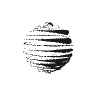

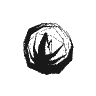

step    0 loss=0.06291 silhouette=0.12558 surface=0.00141
step    1 loss=0.08259 silhouette=0.16493 surface=0.00130
Saved five views and curve.pt to outputs/surface_torus
torus


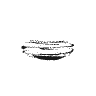

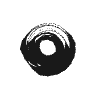

In [7]:
import subprocess
import sys

for shape in ("sphere", "torus"):
    subprocess.run([sys.executable, "surface_filling.py", "--example", shape,
                    "--device", "cpu", "--steps", "2", "--size", "96",
                    "--points", "70", "--output", f"outputs/surface_{shape}"], check=True)
    print(shape)
    display(Image(filename=f"outputs/surface_{shape}/view_0.png"))
    display(Image(filename=f"outputs/surface_{shape}/view_2.png"))